<a href="https://colab.research.google.com/github/julieatkeson/julieandliv/blob/main/julieandliv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project title: The Cost of College and Enrollment Inequality in the United States**

Julie Atkeson and Liv Tawakol

GitHub Pages Link: (insert once published)

In [22]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.ticker as mticker
import matplotlib.pyplot as plt

# Display all columns when previewing data
pd.set_option("display.max_columns", None)


## **Project Goals**

This project aims to examine how the rising cost of college affects who is able to enroll in higher education in the United States. Over the past several decades, tuition costs have increased significantly while household incomes have grown much more slowly. As a result, many students, particularly those from lower and middle-income families, may face financial barriers when deciding whether to attend college.
Our project aims to explore the relationship between family income, tuition costs, and college enrollment. Specifically, we want to better understand whether students from higher-income households are more likely to enroll in college and whether financial aid programs help make college more accessible to students from lower income backgrounds. By combining multiple datasets, we hope to identify trends in college affordability and determine which groups of students may be disproportionately affected by rising costs.
Some of the key questions we hope to explore include:
How have tuition prices changed over time across different types of institutions (public vs. private, two-year vs. four-year)?



*   How have tuition prices changed over time across different types of institutions (public vs. private, two-year vs. four-year)?

*   Are college enrollment rates different for students from different income levels?
*   Does financial aid appear to reduce barriers to college access?


*   Which groups of students appear to be most affected by rising tuition costs?

To answer these questions, we will analyze several publicly available datasets related to tuition, household income, and college enrollment.


## **Collaboration Plan**

Our team will meet weekly to coordinate progress, review each other's work, and discuss next steps in the project. Between meetings, we will communicate through text messages to share updates and ask questions as they arise. We will maintain a shared notes document to track tasks and ideas throughout the project. All code will be developed collaboratively in a shared Google Colab notebook, which allows both team members to contribute to the analysis and review changes easily. This approach ensures that both members remain actively involved in the data processing, analysis, and visualization stages of the project.


## **Data Sources**

### **Dataset 1: U.S. Census Current Population Survey (CPS)**


Source:
https://www.census.gov/data/datasets/time-series/demo/cps/cps-asec.html

This dataset provides detailed demographic and economic information about households in the United States, including income levels and education information. For this milestone, we used the dataset to examine the relationship between household income and college enrollment status. The dataset contains hundreds of variables, so we selected only the columns relevant to income and college enrollment.

A key question we hope to explore with this dataset is: Are students from higher income households more likely to enroll in college?



### **Dataset 2: College Scorecard**

Source: https://collegescorecard.ed.gov/data/


The College Scorecard dataset contains detailed information about colleges and universities in the United States, including tuition costs, financial aid availability, and student outcomes. This dataset will help us examine how tuition levels and financial aid differ across institutions.

A key question we hope to explore is: Do institutions with higher tuition costs provide enough financial aid to maintain access for lower income students?


In [20]:
scorecard_df = pd.read_csv('collegescorecard.csv',
                            low_memory=False,
                            na_values=['PS', 'PrivacySuppressed', 'NULL', 'NA'])
# na_values tells pandas to treat 'PS' (PrivacySuppressed), 'NULL', and 'NA' as missing values (NaN) rather than string
print(scorecard_df.shape)
print(scorecard_df.columns[:10].tolist())
print(scorecard_df[['INSTNM', 'CONTROL', 'TUITIONFEE_OUT', 'NPT4_PUB', 'NPT4_PRIV', 'PCTPELL']].head(3))

(6429, 3306)
['UNITID', 'OPEID', 'OPEID6', 'INSTNM', 'CITY', 'STABBR', 'ZIP', 'ACCREDAGENCY', 'INSTURL', 'NPCURL']
                                INSTNM  CONTROL  TUITIONFEE_OUT  NPT4_PUB  \
0             Alabama A & M University        1         18634.0   14559.0   
1  University of Alabama at Birmingham        1         21864.0   17727.0   
2                   Amridge University        2             NaN       NaN   

   NPT4_PRIV  PCTPELL  
0        NaN   0.6441  
1        NaN   0.3318  
2        NaN   0.6842  


In [21]:
# Select relevant variables
cols = [
    'UNITID', 'INSTNM', 'CONTROL', 'STABBR', 'PREDDEG', 'HIGHDEG',

    # Tuition / Cost
    'TUITIONFEE_IN', 'TUITIONFEE_OUT', 'COSTT4_A',

    # Net price overall (public vs private)
    'NPT4_PUB', 'NPT4_PRIV',

    # Net price by income quintile - public
    'NPT41_PUB', 'NPT42_PUB', 'NPT43_PUB', 'NPT44_PUB', 'NPT45_PUB',

    # Net price by income quintile - private
    'NPT41_PRIV', 'NPT42_PRIV', 'NPT43_PRIV', 'NPT44_PRIV', 'NPT45_PRIV',

    # Access indicators
    'PCTPELL',       # % students receiving Pell grants
    'PCTFLOAN_DCS',  # % receiving federal loans

    # Enrollment size
    'UGDS',
]

df = scorecard_df[cols].copy()

# Keep only 4-year and 2-year degree-granting, currently operating institutions
# PREDDEG: 1=certificate, 2=associate, 3=bachelor's; HIGHDEG: 3=bachelor's, 4=graduate
df = df[df['PREDDEG'].isin([2, 3])]

# Drop rows missing both tuition and net price
df = df.dropna(subset=['COSTT4_A', 'PCTPELL'])

print(df.shape)
print(df.dtypes)
print(df.describe())

(2702, 24)
UNITID              int64
INSTNM             object
CONTROL             int64
STABBR             object
PREDDEG             int64
HIGHDEG             int64
TUITIONFEE_IN     float64
TUITIONFEE_OUT    float64
COSTT4_A          float64
NPT4_PUB          float64
NPT4_PRIV         float64
NPT41_PUB         float64
NPT42_PUB         float64
NPT43_PUB         float64
NPT44_PUB         float64
NPT45_PUB         float64
NPT41_PRIV        float64
NPT42_PRIV        float64
NPT43_PRIV        float64
NPT44_PRIV        float64
NPT45_PRIV        float64
PCTPELL           float64
PCTFLOAN_DCS      float64
UGDS              float64
dtype: object
              UNITID      CONTROL      PREDDEG      HIGHDEG  TUITIONFEE_IN  \
count    2702.000000  2702.000000  2702.000000  2702.000000    2702.000000   
mean   218349.106958     1.617321     2.665063     3.307550   19614.346780   
std    100496.882258     0.626548     0.472056     0.857794   17100.398923   
min    100654.000000     1.000000     2

In [27]:
# --- PREP ---
# Label institution type
df['inst_type'] = df['CONTROL'].map({1: 'Public', 2: 'Private Nonprofit', 3: 'Private For-Profit'})

# Unified net price (use whichever column applies)
df['NPT4'] = df['NPT4_PUB'].fillna(df['NPT4_PRIV'])

# Low-income net price (quintile 1: $0-$30k family income)
df['NPT41'] = df['NPT41_PUB'].fillna(df['NPT41_PRIV'])

# Aid generosity: difference between sticker price and net price for lowest income bracket
df['aid_gap'] = df['COSTT4_A'] - df['NPT41']

# Tuition quartile groups
df['tuition_quartile'] = pd.qcut(df['COSTT4_A'], q=4,
                                  labels=['Q1\n(Lowest)', 'Q2', 'Q3', 'Q4\n(Highest)'])

# ── SUMMARY STAT 1 ──────────────────────────────────────────────────────────
# Average net price for lowest-income students by institution type
print("=" * 60)
print("STAT 1: Avg Net Price for Lowest-Income Students (0-$30k)")
print("        by Institution Type")
print("=" * 60)
stat1 = df.groupby('inst_type')['NPT41'].agg(['mean', 'median', 'count'])
stat1.columns = ['Mean Net Price', 'Median Net Price', 'N']
stat1['Mean Net Price'] = stat1['Mean Net Price'].map('${:,.0f}'.format)
stat1['Median Net Price'] = stat1['Median Net Price'].map('${:,.0f}'.format)
print(stat1.to_string())
print("\nWhy relevant: If high-tuition schools truly offset costs for low-income")
print("students, NPT41 should be low regardless of sticker price.")

# ── SUMMARY STAT 2 ──────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STAT 2: Avg Cost of Attendance & Pell % by Tuition Quartile")
print("=" * 60)
stat2 = df.groupby('tuition_quartile', observed=True).agg(
    Avg_Cost=('COSTT4_A', 'mean'),
    Avg_NetPrice_LoIncome=('NPT41', 'mean'),
    Avg_PctPell=('PCTPELL', 'mean'),
    N=('UNITID', 'count')
).round(0)
stat2['Avg_Cost'] = stat2['Avg_Cost'].map('${:,.0f}'.format)
stat2['Avg_NetPrice_LoIncome'] = stat2['Avg_NetPrice_LoIncome'].map('${:,.0f}'.format)
stat2['Avg_PctPell'] = (stat2['Avg_PctPell'] * 100).map('{:.1f}%'.format)
print(stat2.to_string())
print("\nWhy relevant: Shows whether higher-cost schools compensate with lower")
print("net prices for low-income students, or if costs simply rise together.")

# ── SUMMARY STAT 3 ──────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STAT 3: Aid Generosity — Avg Grant Aid to Lowest-Income Students")
print("        (Cost of Attendance minus Net Price, by Tuition Quartile)")
print("=" * 60)
stat3 = df.groupby('tuition_quartile', observed=True)['aid_gap'].agg(
    ['mean', 'median']
).round(0)
stat3.columns = ['Mean Aid Gap', 'Median Aid Gap']
stat3['Mean Aid Gap'] = stat3['Mean Aid Gap'].map('${:,.0f}'.format)
stat3['Median Aid Gap'] = stat3['Median Aid Gap'].map('${:,.0f}'.format)
print(stat3.to_string())
print("\nWhy relevant: A large aid gap means the school is discounting heavily")
print("for low-income students. A small gap means high cost = high burden.")

STAT 1: Avg Net Price for Lowest-Income Students (0-$30k)
        by Institution Type
                   Mean Net Price Median Net Price     N
inst_type                                               
Private For-Profit        $24,975          $23,896   202
Private Nonprofit         $17,649          $17,482  1205
Public                     $8,075           $7,896  1245

Why relevant: If high-tuition schools truly offset costs for low-income
students, NPT41 should be low regardless of sticker price.

STAT 2: Avg Cost of Attendance & Pell % by Tuition Quartile
                 Avg_Cost Avg_NetPrice_LoIncome Avg_PctPell    N
tuition_quartile                                                
Q1\n(Lowest)      $13,568                $5,370        0.0%  676
Q2                $21,770               $10,980        0.0%  675
Q3                $33,700               $17,935        0.0%  675
Q4\n(Highest)     $60,424               $20,635        0.0%  676

Why relevant: Shows whether higher-cost schoo

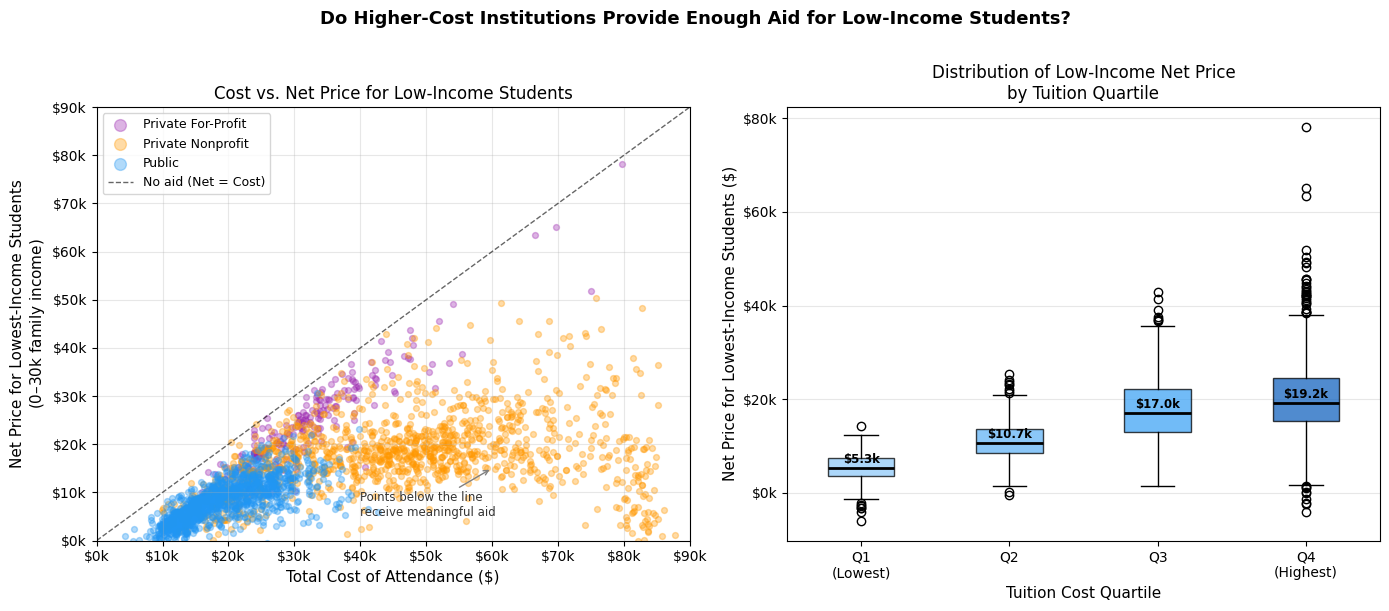

Saved: tuition_vs_aid_eda.png


In [26]:
# ── VISUALIZATION ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Do Higher-Cost Institutions Provide Enough Aid for Low-Income Students?",
             fontsize=13, fontweight='bold', y=1.01)

colors = {'Public': '#2196F3', 'Private Nonprofit': '#FF9800', 'Private For-Profit': '#9C27B0'}

# ── LEFT: Scatter — Cost of Attendance vs Net Price for Lowest-Income Students
ax1 = axes[0]
for itype, group in df.dropna(subset=['NPT41']).groupby('inst_type'):
    ax1.scatter(group['COSTT4_A'], group['NPT41'],
                alpha=0.35, s=18, label=itype, color=colors[itype])

# 45-degree line: net price = cost (no aid at all)
lim = [0, 90000]
ax1.plot(lim, lim, 'k--', linewidth=1, label='No aid (Net = Cost)', alpha=0.6)
ax1.set_xlim(lim); ax1.set_ylim(lim)
ax1.set_xlabel("Total Cost of Attendance ($)", fontsize=11)
ax1.set_ylabel("Net Price for Lowest-Income Students\n($0–$30k family income)", fontsize=11)
ax1.set_title("Cost vs. Net Price for Low-Income Students", fontsize=12)
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax1.legend(fontsize=9, markerscale=2)
ax1.grid(True, alpha=0.3)

# Annotation
ax1.annotate("Points below the line\nreceive meaningful aid",
             xy=(60000, 15000), fontsize=8.5, color='#333333',
             arrowprops=dict(arrowstyle='->', color='gray'),
             xytext=(40000, 5000))

# ── RIGHT: Box plot — Net Price for Lowest-Income by Tuition Quartile
ax2 = axes[1]
quartile_groups = [
    df[df['tuition_quartile'] == q]['NPT41'].dropna().values
    for q in ['Q1\n(Lowest)', 'Q2', 'Q3', 'Q4\n(Highest)']
]
bp = ax2.boxplot(quartile_groups, patch_artist=True, notch=False,
                 medianprops=dict(color='black', linewidth=2))
box_colors = ['#90CAF9', '#64B5F6', '#42A5F5', '#1565C0']
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax2.set_xticklabels(['Q1\n(Lowest)', 'Q2', 'Q3', 'Q4\n(Highest)'])
ax2.set_xlabel("Tuition Cost Quartile", fontsize=11)
ax2.set_ylabel("Net Price for Lowest-Income Students ($)", fontsize=11)
ax2.set_title("Distribution of Low-Income Net Price\nby Tuition Quartile", fontsize=12)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax2.grid(True, alpha=0.3, axis='y')

# Median labels on each box
for i, vals in enumerate(quartile_groups):
    med = np.median(vals)
    ax2.text(i + 1, med + 400, f'${med/1000:.1f}k', ha='center', va='bottom',
             fontsize=8.5, fontweight='bold')

plt.tight_layout()
plt.savefig('tuition_vs_aid_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: tuition_vs_aid_eda.png")

Why these visualizations are important: The scatter plot is central to the research question because it directly compares each institution's sticker price against what low-income students actually pay, with the 45-degree line serving as a clear benchmark — institutions clustered near that line are providing little to no meaningful aid despite their high costs. The box plot complements this by showing the distribution of low-income net prices across tuition quartiles, revealing whether higher-cost schools consistently offset their prices or whether the burden simply rises in tandem with cost. Together, these two visuals expose not just the average trend but also the spread and outliers within each cost tier, which matters because a high average aid amount can mask wide inequality in how generously individual institutions actually serve their lowest-income students.

### **Dataset 3: National Center for Education Statistics (NCES)**


Source:
https://nces.ed.gov/programs/digest/d23/tables/dt23_330.30.asp

This dataset contains historical data on tuition and fees across different types of colleges and universities. It will allow us to examine long-term trends in college costs.

A key question we hope to explore is: How much have tuition costs increased over time across different types of institutions?

